# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [2]:
import pandas as pd
import numpy as np
import os
import time

# Machine Learning & Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Model Persistence & CI/CD Validation
import joblib
import json

# Monitoring & Alerting (Prometheus)
from prometheus_client import start_http_server, Gauge, Counter, Summary

# Visualization (Local Testing before Grafana)
import matplotlib.pyplot as plt
import seaborn as sns

# Logging
import logging
logging.basicConfig(level=logging.INFO)


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [3]:
import kagglehub
path = kagglehub.dataset_download("mczielinski/bitcoin-historical-data")

100%|██████████| 101M/101M [00:05<00:00, 20.2MB/s]

Extracting files...


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [4]:
# List files in the downloaded dataset directory
print(f"Listing files in: {path}")
files_in_dataset = os.listdir(path)
print(files_in_dataset)

# Assuming the main data file is a CSV and taking the first one if multiple exist
csv_files = [f for f in files_in_dataset if f.endswith('.csv')]

if csv_files:
    data_file_path = os.path.join(path, csv_files[0])
    print(f"Loading data from: {data_file_path}")
    df = pd.read_csv(data_file_path)

    # Display the first few rows of the dataset
    print("\nFirst 5 rows of the dataset:")
    print(df.head())

    # Display information about the dataset (data types, non-null counts)
    print("\nDataset Information:")
    df.info()

    # Display descriptive statistics of the dataset
    print("\nDescriptive Statistics:")
    print(df.describe())

    # Check for missing values
    print("\nMissing values per column:")
    print(df.isnull().sum())

else:
    print("No CSV files found in the dataset directory.")

Listing files in: /root/.cache/kagglehub/datasets/mczielinski/bitcoin-historical-data/versions/556
['btcusd_1-min_data.csv']
Loading data from: /root/.cache/kagglehub/datasets/mczielinski/bitcoin-historical-data/versions/556/btcusd_1-min_data.csv

First 5 rows of the dataset:
      Timestamp  Open  High   Low  Close  Volume
0  1.325412e+09  4.58  4.58  4.58   4.58     0.0
1  1.325412e+09  4.58  4.58  4.58   4.58     0.0
2  1.325412e+09  4.58  4.58  4.58   4.58     0.0
3  1.325412e+09  4.58  4.58  4.58   4.58     0.0
4  1.325412e+09  4.58  4.58  4.58   4.58     0.0

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7493443 entries, 0 to 7493442
Data columns (total 6 columns):
 #   Column     Dtype  
---  ------     -----  
 0   Timestamp  float64
 1   Open       float64
 2   High       float64
 3   Low        float64
 4   Close      float64
 5   Volume     float64
dtypes: float64(6)
memory usage: 343.0 MB

Descriptive Statistics:
          Timestamp          Open   

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [6]:
# Check missing values
print("\nMissing values per column in the current DataFrame:")
print(df.isnull().sum())


Missing values per column in the current DataFrame:
Timestamp    0
Open         0
High         0
Low          0
Close        0
Volume       0
dtype: int64


In [7]:
# Check duplicated data
print(f"Jumlah baris duplikat sebelum penghapusan: {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)
print(f"Jumlah baris setelah penghapusan duplikat: {len(df)}")

Jumlah baris duplikat sebelum penghapusan: 0
Jumlah baris setelah penghapusan duplikat: 7493443


In [8]:
# Standardize features

# Check whether 'Timestamp' is still in column or is already in index format
if 'Timestamp' in df.columns:
    df['Timestamp'] = pd.to_datetime(df['Timestamp'], unit='s')
    df = df.set_index('Timestamp')
elif df.index.name != 'Timestamp':
    # Handle case where Timestamp might be in index but not named correctly
    # Assuming the current index is the timestamp if it's already datetime like
    if pd.api.types.is_numeric_dtype(df.index):
        df.index = pd.to_datetime(df.index, unit='s')
    df.index.name = 'Timestamp'

print("\nDataFrame setelah konversi Timestamp dan dijadikan index:")
print(df.head())

# Features that are going to be standardized
features_to_scale = ['Open', 'High', 'Low', 'Close', 'Volume']

# Initialize StandardScaler
scaler = StandardScaler()

# Implement standardization on chosen features
existing_features_to_scale = [f for f in features_to_scale if f in df.columns]

if existing_features_to_scale:
    df[existing_features_to_scale] = scaler.fit_transform(df[existing_features_to_scale])
    print("\nDataFrame setelah standarisasi fitur:")
    print(df.head())
    print("\nStatistik deskriptif fitur setelah standarisasi:")
    print(df[existing_features_to_scale].describe())
else:
    print("Tidak ada fitur yang relevan untuk distandarisasi ditemukan dalam DataFrame.")


DataFrame setelah konversi Timestamp dan dijadikan index:
                     Open  High   Low  Close  Volume
Timestamp                                           
2012-01-01 10:01:00  4.58  4.58  4.58   4.58     0.0
2012-01-01 10:02:00  4.58  4.58  4.58   4.58     0.0
2012-01-01 10:03:00  4.58  4.58  4.58   4.58     0.0
2012-01-01 10:04:00  4.58  4.58  4.58   4.58     0.0
2012-01-01 10:05:00  4.58  4.58  4.58   4.58     0.0

DataFrame setelah standarisasi fitur:
                         Open      High       Low     Close    Volume
Timestamp                                                            
2012-01-01 10:01:00 -0.731753 -0.731814 -0.731688 -0.731753 -0.231891
2012-01-01 10:02:00 -0.731753 -0.731814 -0.731688 -0.731753 -0.231891
2012-01-01 10:03:00 -0.731753 -0.731814 -0.731688 -0.731753 -0.231891
2012-01-01 10:04:00 -0.731753 -0.731814 -0.731688 -0.731753 -0.231891
2012-01-01 10:05:00 -0.731753 -0.731814 -0.731688 -0.731753 -0.231891

Statistik deskriptif fitur setelah stand

In [9]:
from scipy.stats import zscore

# Features to check for outlier
features_to_check_outliers = ['Open', 'High', 'Low', 'Close', 'Volume']

print("\nDeteksi Outlier menggunakan Z-score:")

# Setting z-score threshold
z_score_threshold = 3

outlier_counts = {}
for feature in features_to_check_outliers:
    # Calculating z-score for every feature
    z_scores = np.abs(zscore(df[feature]))

    # Outlier identification
    outliers = df[z_scores > z_score_threshold]
    outlier_counts[feature] = len(outliers)

    print(f"Fitur '{feature}': {len(outliers)} outlier terdeteksi (Z-score > {z_score_threshold})")

    # Menampilkan contoh outlier (jika ada)
    if not outliers.empty:
        print(f"  Contoh outlier pada '{feature}':")
        print(outliers[[feature]].head())

print("\nRingkasan jumlah outlier per fitur:")
for feature, count in outlier_counts.items():
    print(f"- {feature}: {count}")


Deteksi Outlier menggunakan Z-score:
Fitur 'Open': 76401 outlier terdeteksi (Z-score > 3)
  Contoh outlier pada 'Open':
                         Open
Timestamp                    
2025-07-10 21:19:00  3.001259
2025-07-10 21:20:00  3.031090
2025-07-10 21:21:00  3.015527
2025-07-10 21:22:00  3.006856
2025-07-10 21:23:00  3.014039
Fitur 'High': 76232 outlier terdeteksi (Z-score > 3)
  Contoh outlier pada 'High':
                         High
Timestamp                    
2025-07-10 21:18:00  3.010531
2025-07-10 21:19:00  3.052582
2025-07-10 21:20:00  3.038511
2025-07-10 21:21:00  3.017486
2025-07-10 21:22:00  3.014154
Fitur 'Low': 76608 outlier terdeteksi (Z-score > 3)
  Contoh outlier pada 'Low':
                          Low
Timestamp                    
2025-07-10 21:20:00  3.014098
2025-07-10 21:21:00  3.006072
2025-07-10 21:22:00  3.007949
2025-07-10 21:23:00  3.015102
2025-07-10 21:24:00  3.026688
Fitur 'Close': 76417 outlier terdeteksi (Z-score > 3)
  Contoh outlier pada 'Close':


In [10]:
print("\nMenangani Outlier menggunakan Capping (Z-score):")

for feature in features_to_check_outliers:
    # Menghitung mean dan standard deviation dari fitur
    # Gunakan df[feature] secara langsung karena sudah distandarisasi
    mean_val = df[feature].mean()
    std_val = df[feature].std()

    # Menghitung batas atas dan bawah berdasarkan Z-score threshold
    upper_bound = mean_val + z_score_threshold * std_val
    lower_bound = mean_val - z_score_threshold * std_val

    # Menerapkan capping
    # Nilai di atas upper_bound akan diganti dengan upper_bound
    # Nilai di bawah lower_bound akan diganti dengan lower_bound
    df[feature] = np.where(df[feature] > upper_bound, upper_bound, df[feature])
    df[feature] = np.where(df[feature] < lower_bound, lower_bound, df[feature])
    print(f"  Outlier untuk fitur '{feature}' telah ditangani dengan capping.")

print("\nDataFrame setelah penanganan outlier:")
print(df.head())

print("\nStatistik deskriptif fitur setelah penanganan outlier (capping):")
print(df[features_to_check_outliers].describe())


Menangani Outlier menggunakan Capping (Z-score):
  Outlier untuk fitur 'Open' telah ditangani dengan capping.
  Outlier untuk fitur 'High' telah ditangani dengan capping.
  Outlier untuk fitur 'Low' telah ditangani dengan capping.
  Outlier untuk fitur 'Close' telah ditangani dengan capping.
  Outlier untuk fitur 'Volume' telah ditangani dengan capping.

DataFrame setelah penanganan outlier:
                         Open      High       Low     Close    Volume
Timestamp                                                            
2012-01-01 10:01:00 -0.731753 -0.731814 -0.731688 -0.731753 -0.231891
2012-01-01 10:02:00 -0.731753 -0.731814 -0.731688 -0.731753 -0.231891
2012-01-01 10:03:00 -0.731753 -0.731814 -0.731688 -0.731753 -0.231891
2012-01-01 10:04:00 -0.731753 -0.731814 -0.731688 -0.731753 -0.231891
2012-01-01 10:05:00 -0.731753 -0.731814 -0.731688 -0.731753 -0.231891

Statistik deskriptif fitur setelah penanganan outlier (capping):
               Open          High           Low 

### Visualize distribution of features

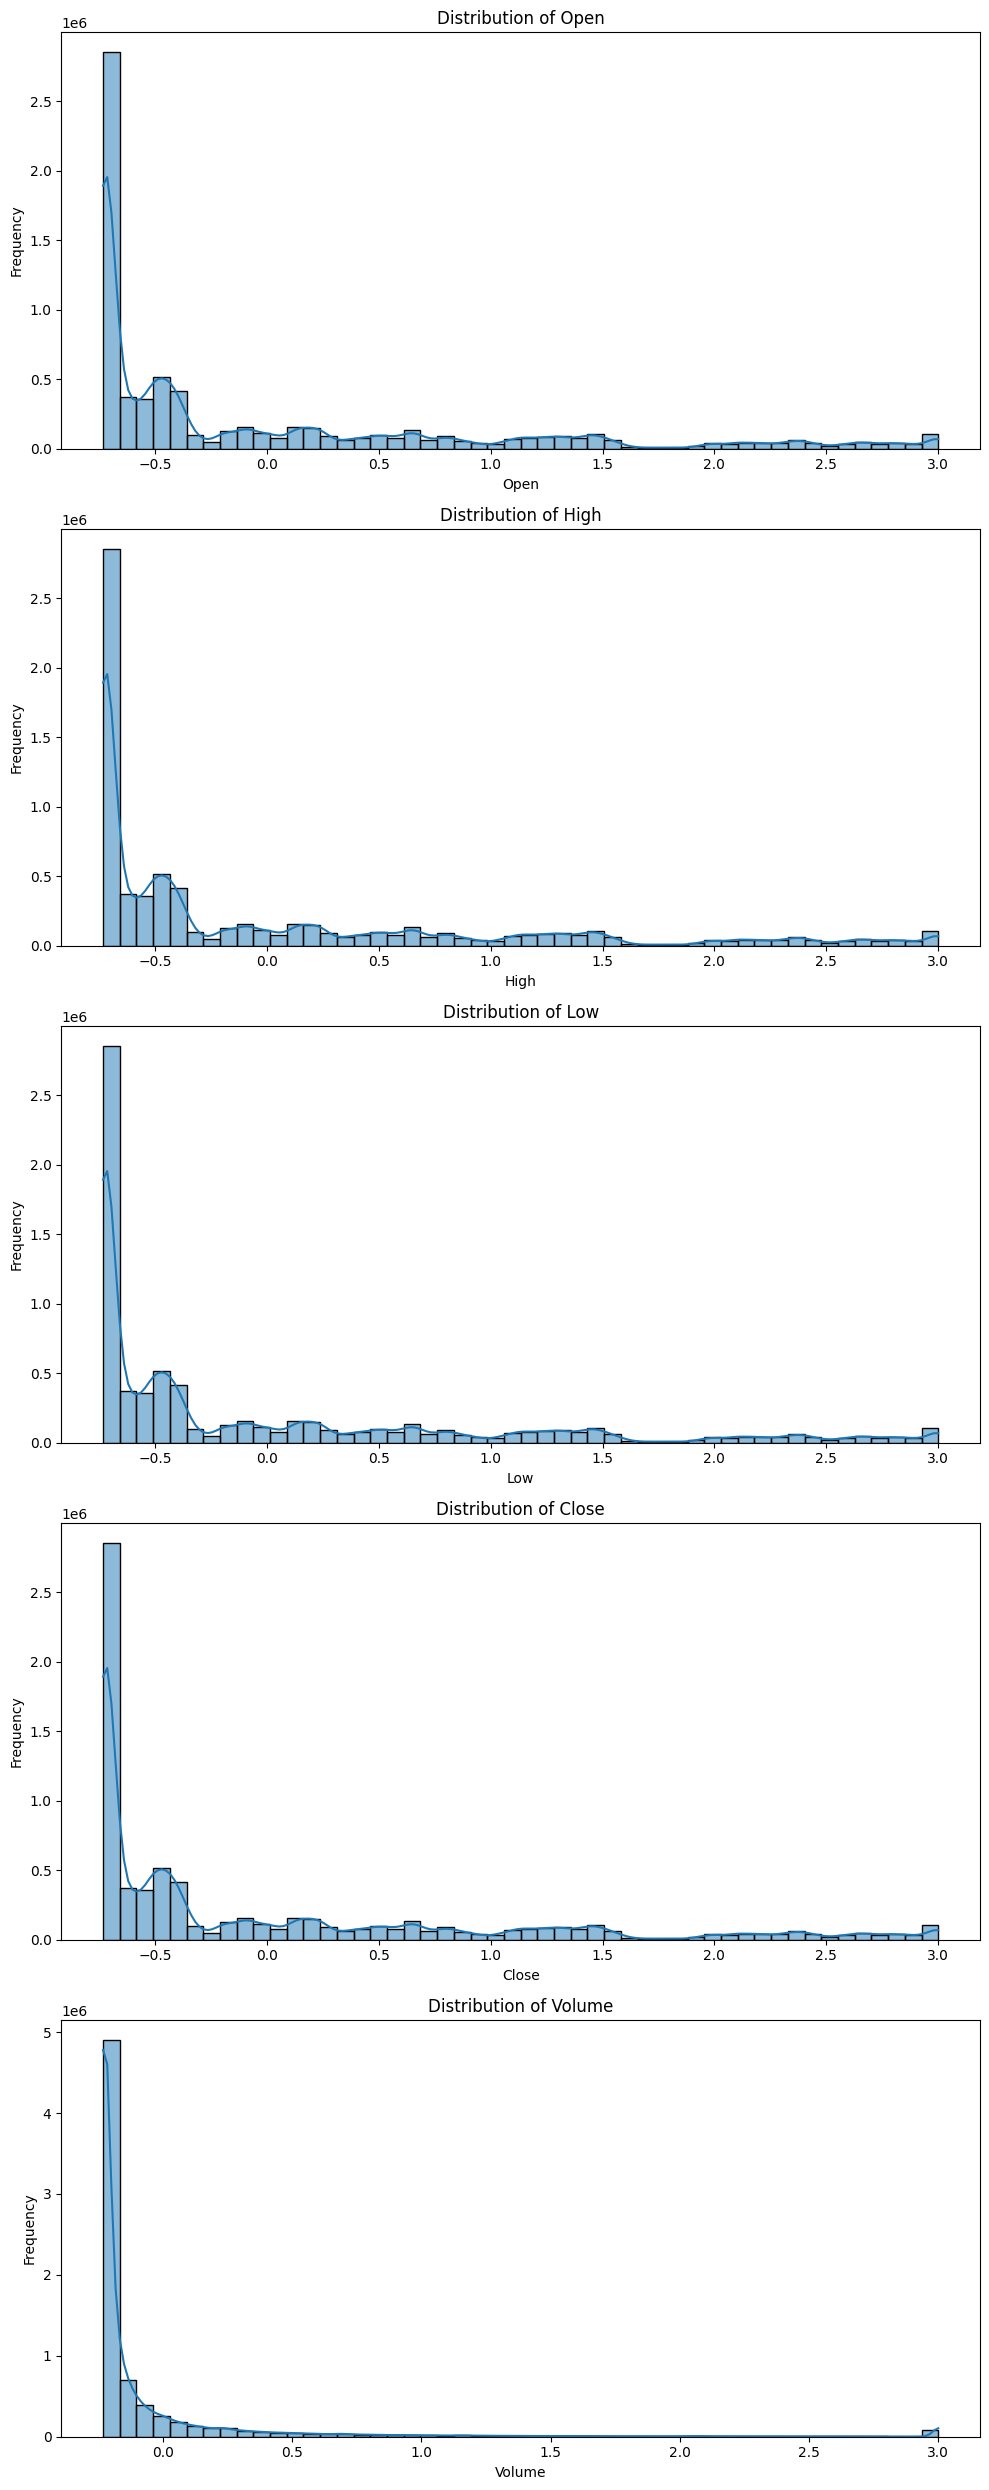

In [11]:
# Features to plot histograms for
features_to_plot = ['Open', 'High', 'Low', 'Close', 'Volume']

# Create subplots for each feature
fig, axes = plt.subplots(len(features_to_plot), 1, figsize=(10, 5 * len(features_to_plot)))

for i, feature in enumerate(features_to_plot):
    sns.histplot(df[feature], kde=True, ax=axes[i], bins=50)
    axes[i].set_title(f'Distribution of {feature}')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

### Calculate Correlation Matrix


Correlation Matrix:


,Open,High,Low,Close,Volume
Open,1.000000,1.000000,1.000000,1.00000,-0.139906
High,1.000000,1.000000,1.000000,1.00000,-0.139807
Low,1.000000,1.000000,1.000000,1.00000,-0.140017
Close,1.000000,1.000000,1.000000,1.00000,-0.139910
Volume,-0.139906,-0.139807,-0.140017,-0.13991,1.000000


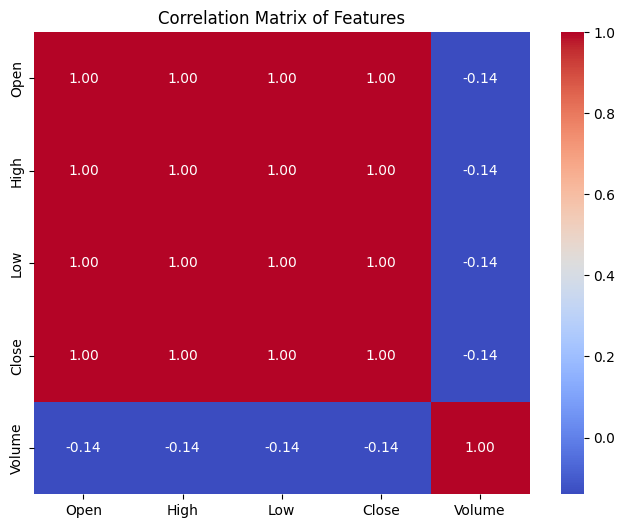

In [12]:
# Calculate the correlation matrix
correlation_matrix = df[features_to_plot].corr()

print("\nCorrelation Matrix:")
display(correlation_matrix)

# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Features')
plt.show()